# NB04: Putirka benchmark with dual tables (fair + practical)

## Purpose / Inputs / Outputs / Canonical decisions

**Purpose:** Benchmark the canonical opx-liq ML model against the Putirka (2008) thermobarometer using `Thermobar`. Reports a unified table with three scopes (full / Putirka-valid subset / intersection), paired Wilcoxon tests on |residuals|, Delta-RMSE bootstrap CIs, and a failure-mode Mann-Whitney on Putirka-fail vs Putirka-valid.

**Inputs:** `data/processed/opx_clean_opx_liq.parquet`, `results/nb03_winning_configurations.json`, canonical RF models.

**Outputs:** `results/nb04_putirka_comparison.csv` (+ `_fair`, `_practical`, `_unified`), `results/nb04_putirka_vs_ml.csv` (legacy schema for NBF fig10), `results/nb04_putirka_vs_ml_wilcoxon.csv`, `figures/fig_nb04_putirka_comparison.{png,pdf}`.

**Canonical decisions:** Uses Putirka Option 2 (passing true observed P and T as inputs) as the canonical Putirka scope for the legacy comparison CSV. The OPERATOR DECISION block (A/B/C) controls which scope becomes the manuscript headline.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    EXPETDB, LEPR_XLSX, LIN2023_NATURAL,
    FE3_FET_RATIO, KD_FEMG_MIN, KD_FEMG_MAX, WO_MAX_MOL_PCT,
    P_CEILING_KBAR, CATION_SUM_MIN, CATION_SUM_MAX,
    OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX,
    SEED_SPLIT, SEED_MODEL, SEED_NOISE_AUG, SEED_KMEANS,
    OPX_RAW_OXIDES, OPX_FULL_OXIDES, LIQ_OXIDES,
)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import Thermobar as pt

In [2]:
# Canonical features and prediction helpers from src/ (one source of truth).
from src.features import (
    build_feature_matrix,
    make_raw_features,
    make_alr_features,
    make_pwlr_features,
    augment_dataframe,
)
from src.models import predict_median, predict_iqr


In [3]:
# Force RF rows for fair comparison regardless of overall winner
import ast
from sklearn.ensemble import RandomForestRegressor

results_all = pd.read_csv(RESULTS / 'nb03_multi_seed_summary.csv')
rf_liq = results_all[(results_all.track=='opx_liq') & (results_all.model_name=='RF')]

rf_T = rf_liq[rf_liq.target=='T_C'].sort_values('rmse_test_mean').iloc[0]
rf_P = rf_liq[rf_liq.target=='P_kbar'].sort_values('rmse_test_mean').iloc[0]

fs_T = rf_T['feature_set']
fs_P = rf_P['feature_set']
print(f'Fair-comparison RF opx-liq: T uses {fs_T}, P uses {fs_P}')


def get_or_train_rf(target, feat_set):
    """Load the saved RF-per-target model, or retrain it from the canonical
    seed-42 best_params if NB03 did not persist that specific combo."""
    fname = f'model_RF_{target}_opx_liq_{feat_set}.joblib'
    fpath = MODELS / fname
    if fpath.exists():
        return joblib.load(fpath)

    multi = pd.read_csv(RESULTS / 'nb03_multi_seed_results.csv')
    row = multi[(multi.track == 'opx_liq') &
                (multi.model_name == 'RF') &
                (multi.feature_set == feat_set) &
                (multi.target == target) &
                (multi.split_seed == 42)].iloc[0]
    try:
        params = ast.literal_eval(row['best_params'])
    except Exception:
        import json as _json
        params = _json.loads(row['best_params'])

    df_full = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
    tr_idx = np.load(DATA_SPLITS / 'train_indices_opx_liq.npy')
    df_tr = df_full.loc[tr_idx]
    X_tr, _ = build_feature_matrix(df_tr, feat_set, use_liq=True)
    y_tr = df_tr[target].values

    mdl = RandomForestRegressor(**params, random_state=SEED_MODEL, n_jobs=-1)
    mdl.fit(X_tr, y_tr)
    joblib.dump(mdl, fpath)
    print(f'Re-trained and cached {fname}')
    return mdl


model_T_ml = get_or_train_rf('T_C', fs_T)
model_P_ml = get_or_train_rf('P_kbar', fs_P)


Fair-comparison RF opx-liq: T uses pwlr, P uses raw


In [4]:
# Load opx-liq test set
df_liq = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
test_idx = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_test = df_liq.loc[test_idx].copy()
print(f'Test set: {len(df_test)} experiments from {df_test["Citation"].nunique()} studies')

Test set: 174 experiments from 19 studies


In [5]:
# Format for Thermobar
fe3_array = np.full(len(df_test), FE3_FET_RATIO)

if 'H2O_Liq' in df_test.columns:
    h2o_array = df_test['H2O_Liq'].fillna(0).values.astype(float)
else:
    h2o_array = np.zeros(len(df_test))
    print('WARNING: H2O_Liq not found, using zeros')

def g(col, default=0):
    if col in df_test.columns:
        return df_test[col].fillna(default).values.astype(float)
    return np.full(len(df_test), default, dtype=float)

opx_test = pd.DataFrame({
    'SiO2_Opx': g('SiO2'),
    'TiO2_Opx': g('TiO2'),
    'Al2O3_Opx': g('Al2O3'),
    'FeOt_Opx': g('FeO_total'),
    'MgO_Opx': g('MgO'),
    'CaO_Opx': g('CaO'),
    'MnO_Opx': g('MnO'),
    'Cr2O3_Opx': g('Cr2O3'),
    'Na2O_Opx': g('Na2O'),
})

liq_test = pd.DataFrame({
    'SiO2_Liq': g('liq_SiO2'),
    'TiO2_Liq': g('liq_TiO2'),
    'Al2O3_Liq': g('liq_Al2O3'),
    'FeOt_Liq': g('liq_FeO'),
    'MgO_Liq': g('liq_MgO'),
    'CaO_Liq': g('liq_CaO'),
    'Na2O_Liq': g('liq_Na2O'),
    'K2O_Liq': g('liq_K2O'),
    'MnO_Liq': g('liq_MnO' if 'liq_MnO' in df_test.columns else 'FeO_total') * 0,
    'Cr2O3_Liq': np.zeros(len(df_test)),
    'P2O5_Liq': np.zeros(len(df_test)),
    'Fe3Fet_Liq': fe3_array,
    'H2O_Liq': h2o_array,
})

y_T_true = df_test['T_C'].values.astype(float)
y_P_true = df_test['P_kbar'].values.astype(float)

In [6]:
# Helper to coerce Thermobar output to numpy array
def to_array(x, key_T=False):
    if isinstance(x, pd.DataFrame):
        # Try common column names
        for col in ['T_K_calc', 'T_C_calc', 'T_K', 'T_C', 'Temperature_K',
                    'P_kbar_calc', 'P_kbar', 'Pressure_kbar']:
            if col in x.columns:
                arr = x[col].values.astype(float)
                if 'T_K' in col or col == 'Temperature_K':
                    arr = arr - 273.15
                return arr
        return x.iloc[:, 0].values.astype(float)
    if isinstance(x, pd.Series):
        arr = x.values.astype(float)
    else:
        arr = np.asarray(x, dtype=float)
    return arr

def safe_thermobar(func, **kwargs):
    try:
        return to_array(func(**kwargs))
    except Exception as e:
        print(f'  {func.__name__} FAILED: {e}')
        return np.full(len(df_test), np.nan)

In [7]:
# Option 2: true P/T as input
print('Option 2 (true P/T as input):')
T_put_28a = safe_thermobar(
    pt.calculate_opx_liq_temp,
    equationT='T_Put2008_eq28a', opx_comps=opx_test, liq_comps=liq_test,
    P=y_P_true, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
)
T_put_28b = safe_thermobar(
    pt.calculate_opx_liq_temp,
    equationT='T_Put2008_eq28b_opx_sat', opx_comps=opx_test, liq_comps=liq_test,
    P=y_P_true, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
)
P_put_29a = safe_thermobar(
    pt.calculate_opx_liq_press,
    equationP='P_Put2008_eq29a', opx_comps=opx_test, liq_comps=liq_test,
    T=y_T_true + 273.15, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
)
P_put_29c = safe_thermobar(
    pt.calculate_opx_only_press,
    equationP='P_Put2008_eq29c', opx_comps=opx_test, T=y_T_true + 273.15,
)
# Thermobar T_Put2008_eq28a/28b return T in Kelvin; convert to Celsius
T_put_28a = T_put_28a - 273.15
T_put_28b = T_put_28b - 273.15

# Sanity bounds: mark physically implausible Putirka outputs as failures.
# Putirka 28a/29a are unstable for some opx-liq pairs and produce extreme outliers.
# Reasonable bounds: T in 400-1900 C, P in -2 to 100 kbar (matches training range).
def clip_to_failure(arr, lo, hi):
    arr = np.asarray(arr, dtype=float)
    bad = (arr < lo) | (arr > hi)
    arr[bad] = np.nan
    return arr

T_put_28a = clip_to_failure(T_put_28a, 400, 1900)
T_put_28b = clip_to_failure(T_put_28b, 400, 1900)
P_put_29a = clip_to_failure(P_put_29a, -2, 100)
P_put_29c = clip_to_failure(P_put_29c, -2, 100)

print(f'  28a: n_valid={np.isfinite(T_put_28a).sum()}, mean={np.nanmean(T_put_28a):.0f}')
print(f'  28b: n_valid={np.isfinite(T_put_28b).sum()}, mean={np.nanmean(T_put_28b):.0f}')
print(f'  29a: n_valid={np.isfinite(P_put_29a).sum()}, mean={np.nanmean(P_put_29a):.1f}')
print(f'  29c: n_valid={np.isfinite(P_put_29c).sum()}, mean={np.nanmean(P_put_29c):.1f}')

Option 2 (true P/T as input):


  28a: n_valid=159, mean=1302
  28b: n_valid=161, mean=1294
  29a: n_valid=126, mean=11.1
  29c: n_valid=145, mean=10.4


In [8]:
# Option 1: iterative solver
print('Option 1 (iterative):')
try:
    iter_result = pt.calculate_opx_liq_press_temp(
        equationT='T_Put2008_eq28a',
        equationP='P_Put2008_eq29a',
        opx_comps=opx_test, liq_comps=liq_test,
        Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
        iterations=30,
    )
    if isinstance(iter_result, pd.DataFrame):
        print('  columns:', iter_result.columns.tolist()[:10])
        T_col = next((c for c in ['T_K_calc','T_C_calc','T_K','Temperature_K'] if c in iter_result.columns), None)
        P_col = next((c for c in ['P_kbar_calc','P_kbar','Pressure_kbar'] if c in iter_result.columns), None)
        T_put_iter = iter_result[T_col].values.astype(float) if T_col else np.full(len(df_test), np.nan)
        P_put_iter = iter_result[P_col].values.astype(float) if P_col else np.full(len(df_test), np.nan)
        if T_col and 'K' in T_col:
            T_put_iter = T_put_iter - 273.15
    else:
        T_put_iter = np.full(len(df_test), np.nan)
        P_put_iter = np.full(len(df_test), np.nan)
    T_put_iter = clip_to_failure(T_put_iter, 400, 1900)
    P_put_iter = clip_to_failure(P_put_iter, -2, 100)
    print(f'  T_iter n_valid={np.isfinite(T_put_iter).sum()}, mean={np.nanmean(T_put_iter):.0f}')
    print(f'  P_iter n_valid={np.isfinite(P_put_iter).sum()}, mean={np.nanmean(P_put_iter):.1f}')
except Exception as e:
    print(f'  iterative FAILED: {e}')
    T_put_iter = np.full(len(df_test), np.nan)
    P_put_iter = np.full(len(df_test), np.nan)

Option 1 (iterative):


  columns: ['P_kbar_calc', 'T_K_calc', 'Delta_P_kbar_Iter', 'Delta_T_K_Iter']
  T_iter n_valid=126, mean=1303
  P_iter n_valid=126, mean=11.4


In [9]:
# ML predictions + Option 3 (ML P/T fed to Putirka)
X_test_T, _ = build_feature_matrix(df_test, fs_T, use_liq=True)
X_test_P, _ = build_feature_matrix(df_test, fs_P, use_liq=True)
T_ml_pred = model_T_ml.predict(X_test_T)
P_ml_pred = model_P_ml.predict(X_test_P)

print(f'ML: T RMSE={np.sqrt(mean_squared_error(y_T_true, T_ml_pred)):.2f}, R2={r2_score(y_T_true, T_ml_pred):.3f}')
print(f'ML: P RMSE={np.sqrt(mean_squared_error(y_P_true, P_ml_pred)):.2f}, R2={r2_score(y_P_true, P_ml_pred):.3f}')

print('Option 3 (ML-P fed to Putirka T, ML-T fed to Putirka P):')
T_put_mlP = safe_thermobar(
    pt.calculate_opx_liq_temp,
    equationT='T_Put2008_eq28a', opx_comps=opx_test, liq_comps=liq_test,
    P=P_ml_pred, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
)
P_put_mlT = safe_thermobar(
    pt.calculate_opx_liq_press,
    equationP='P_Put2008_eq29a', opx_comps=opx_test, liq_comps=liq_test,
    T=T_ml_pred + 273.15, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array,
)
T_put_mlP = T_put_mlP - 273.15
T_put_mlP = clip_to_failure(T_put_mlP, 400, 1900)
P_put_mlT = clip_to_failure(P_put_mlT, -2, 100)
print(f'  T_put_mlP mean={np.nanmean(T_put_mlP):.0f}')
print(f'  P_put_mlT mean={np.nanmean(P_put_mlT):.1f}')

ML: T RMSE=85.05, R2=0.624
ML: P RMSE=5.39, R2=0.687
Option 3 (ML-P fed to Putirka T, ML-T fed to Putirka P):


  T_put_mlP mean=1308
  P_put_mlT mean=11.4


In [10]:
# Dual tables: Fair and Practical
def compute_row(method, target, y_true, y_pred, valid_mask):
    yt = y_true[valid_mask]; yp = y_pred[valid_mask]
    finite = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[finite], yp[finite]
    if len(yt) == 0:
        return {'Method': method, 'Target': target, 'RMSE': np.nan,
                'MAE': np.nan, 'R2': np.nan, 'n_test': 0}
    return {
        'Method': method, 'Target': target,
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE': mean_absolute_error(yt, yp),
        'R2': r2_score(yt, yp),
        'n_test': len(yt),
    }

T_arrays = {
    'Putirka 28a (true P)': T_put_28a,
    'Putirka 28b_opx_sat (true P)': T_put_28b,
    'Putirka iterative (28a+29a)': T_put_iter,
    'Putirka 28a (ML P)': T_put_mlP,
    'ML-RF opx-liq': T_ml_pred,
}
P_arrays = {
    'Putirka 29a (true T)': P_put_29a,
    'Putirka 29c (opx-only, true T)': P_put_29c,
    'Putirka iterative (28a+29a)': P_put_iter,
    'Putirka 29a (ML T)': P_put_mlT,
    'ML-RF opx-liq': P_ml_pred,
}

T_masks = [np.isfinite(arr) for arr in T_arrays.values()]
P_masks = [np.isfinite(arr) for arr in P_arrays.values()]
T_all_valid = np.logical_and.reduce(T_masks)
P_all_valid = np.logical_and.reduce(P_masks)
print(f'T: all-method valid on {T_all_valid.sum()}/{len(y_T_true)}')
print(f'P: all-method valid on {P_all_valid.sum()}/{len(y_P_true)}')

# Fair table: same sample subset for all methods
fair_rows = []
for name, arr in T_arrays.items():
    fair_rows.append(compute_row(name, 'T', y_T_true, arr, T_all_valid))
for name, arr in P_arrays.items():
    fair_rows.append(compute_row(name, 'P', y_P_true, arr, P_all_valid))
fair_df = pd.DataFrame(fair_rows)
fair_df.to_csv(RESULTS / 'nb04_putirka_comparison_fair.csv', index=False)
fair_df.to_csv(RESULTS / 'nb04_putirka_comparison.csv', index=False)
print('\nFAIR comparison:')
print(fair_df.round(3).to_string(index=False))

T: all-method valid on 124/174
P: all-method valid on 107/174

FAIR comparison:
                        Method Target   RMSE    MAE    R2  n_test
          Putirka 28a (true P)      T 77.050 42.718 0.631     124
  Putirka 28b_opx_sat (true P)      T 81.432 49.497 0.587     124
   Putirka iterative (28a+29a)      T 77.842 49.592 0.623     124
            Putirka 28a (ML P)      T 79.854 52.676 0.603     124
                 ML-RF opx-liq      T 85.760 56.766 0.542     124
          Putirka 29a (true T)      P  3.834  2.950 0.780     107
Putirka 29c (opx-only, true T)      P  4.963  3.842 0.631     107
   Putirka iterative (28a+29a)      P  3.818  2.918 0.782     107
            Putirka 29a (ML T)      P  3.800  2.850 0.784     107
                 ML-RF opx-liq      P  4.510  3.520 0.695     107


In [11]:
# Practical table: ML on all samples, Putirka failure rate
practical_rows = []
practical_rows.append({
    'Method': 'ML-RF opx-liq (all test)', 'Target': 'T',
    'RMSE': np.sqrt(mean_squared_error(y_T_true, T_ml_pred)),
    'MAE': mean_absolute_error(y_T_true, T_ml_pred),
    'R2': r2_score(y_T_true, T_ml_pred),
    'n_test': len(y_T_true),
    'failure_pct': 0.0,
})
practical_rows.append({
    'Method': 'ML-RF opx-liq (all test)', 'Target': 'P',
    'RMSE': np.sqrt(mean_squared_error(y_P_true, P_ml_pred)),
    'MAE': mean_absolute_error(y_P_true, P_ml_pred),
    'R2': r2_score(y_P_true, P_ml_pred),
    'n_test': len(y_P_true),
    'failure_pct': 0.0,
})
practical_rows.append({
    'Method': 'Putirka failure rate', 'Target': 'T',
    'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan,
    'n_test': int((~T_all_valid).sum()),
    'failure_pct': 100.0 * (~T_all_valid).sum() / len(y_T_true),
})
practical_rows.append({
    'Method': 'Putirka failure rate', 'Target': 'P',
    'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan,
    'n_test': int((~P_all_valid).sum()),
    'failure_pct': 100.0 * (~P_all_valid).sum() / len(y_P_true),
})
practical_df = pd.DataFrame(practical_rows)
practical_df.to_csv(RESULTS / 'nb04_putirka_comparison_practical.csv', index=False)
print('PRACTICAL comparison:')
print(practical_df.round(3).to_string(index=False))

PRACTICAL comparison:
                  Method Target   RMSE    MAE    R2  n_test  failure_pct
ML-RF opx-liq (all test)      T 85.051 57.609 0.624     174        0.000
ML-RF opx-liq (all test)      P  5.394  3.993 0.687     174        0.000
    Putirka failure rate      T    NaN    NaN   NaN      50       28.736
    Putirka failure rate      P    NaN    NaN   NaN      67       38.506


In [12]:
# Legacy CSV for NBF fig 10 (schema: obs_*, putirka_pred_*, ml_pred_*).
# Option 2 Putirka predictions (true P/T as input) are the canonical Putirka
# column since that is the configuration reported as the Putirka benchmark.
legacy_df = pd.DataFrame({
    'obs_T_C':             y_T_true,
    'obs_P_kbar':          y_P_true,
    'putirka_pred_T_C':    T_put_28a,
    'putirka_pred_P_kbar': P_put_29a,
    'ml_pred_T_C':         T_ml_pred,
    'ml_pred_P_kbar':      P_ml_pred,
})
legacy_df.to_csv(RESULTS / 'nb04_putirka_vs_ml.csv', index=False)
print(f'Wrote legacy {RESULTS.name}/nb04_putirka_vs_ml.csv ({len(legacy_df)} rows)')


Wrote legacy results/nb04_putirka_vs_ml.csv (174 rows)


## Part 1: Unified benchmark reframe (v5)

The earlier Fair/Practical dual-table framing hid the fact that the denominator
shifts between ML and Putirka. Here we report three explicit scopes:

- **full**: every opx-liq test experiment (n = N_full). ML is evaluated on all of
  these; Putirka is reported with an explicit failure rate.
- **putirka_valid**: intersection of Putirka-28a and Putirka-29a valid outputs
  (physically plausible T and P). Reports RMSE for every method on the same
  Putirka-valid subset.
- **intersection**: putirka_valid AND ML-prediction finite (typically identical
  to putirka_valid since ML never fails). This is the strict apples-to-apples
  comparison used for paired significance tests.

For every (method, target, scope) we report RMSE with a 95% bootstrap CI
(B = 2000). Paired Wilcoxon signed-rank tests on absolute residuals compare
ML-RF opx-liq vs each Putirka variant on the intersection scope.


In [13]:
# Part 1a: unified_benchmark_table (three denominators)
from scipy import stats

BOOT_B = 2000
BOOT_RNG = np.random.default_rng(42)

# Putirka arrays already defined above. ML arrays: T_ml_pred, P_ml_pred.
T_methods = {
    'Putirka 28a (true P)':         T_put_28a,
    'Putirka 28b_opx_sat (true P)': T_put_28b,
    'Putirka iterative (28a+29a)':  T_put_iter,
    'Putirka 28a (ML P)':           T_put_mlP,
    'ML-RF opx-liq':                T_ml_pred,
}
P_methods = {
    'Putirka 29a (true T)':           P_put_29a,
    'Putirka 29c (opx-only, true T)': P_put_29c,
    'Putirka iterative (28a+29a)':    P_put_iter,
    'Putirka 29a (ML T)':             P_put_mlT,
    'ML-RF opx-liq':                  P_ml_pred,
}

# Define scopes.
T_putirka_valid = (np.isfinite(T_put_28a) & np.isfinite(T_put_28b) &
                   np.isfinite(T_put_iter) & np.isfinite(T_put_mlP))
P_putirka_valid = (np.isfinite(P_put_29a) & np.isfinite(P_put_29c) &
                   np.isfinite(P_put_iter) & np.isfinite(P_put_mlT))

T_intersection = T_putirka_valid & np.isfinite(T_ml_pred) & np.isfinite(y_T_true)
P_intersection = P_putirka_valid & np.isfinite(P_ml_pred) & np.isfinite(y_P_true)

N_full = len(y_T_true)


def rmse_with_ci(y_true, y_pred, mask, B=BOOT_B, rng=BOOT_RNG):
    m = mask & np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan, np.nan, np.nan, int(m.sum())
    yt = y_true[m]; yp = y_pred[m]
    n = len(yt)
    point = float(np.sqrt(np.mean((yt - yp) ** 2)))
    idx = rng.integers(0, n, size=(B, n))
    boots = np.sqrt(np.mean((yt[idx] - yp[idx]) ** 2, axis=1))
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return point, float(lo), float(hi), n


unified_rows = []
for target, methods, y_true, scopes in [
    ('T', T_methods, y_T_true,
     {'full':           np.isfinite(y_T_true),
      'putirka_valid':  T_putirka_valid,
      'intersection':   T_intersection}),
    ('P', P_methods, y_P_true,
     {'full':           np.isfinite(y_P_true),
      'putirka_valid':  P_putirka_valid,
      'intersection':   P_intersection}),
]:
    for scope_name, scope_mask in scopes.items():
        for method_name, pred in methods.items():
            rmse, lo, hi, n = rmse_with_ci(y_true, pred, scope_mask)
            unified_rows.append({
                'target':        target,
                'scope':         scope_name,
                'method':        method_name,
                'n':             n,
                'rmse':          rmse,
                'rmse_ci_lo':    lo,
                'rmse_ci_hi':    hi,
                'failure_pct':   (100.0 * (~np.isfinite(pred)).sum() / N_full
                                  if method_name.startswith('Putirka') else 0.0),
            })

unified_df = pd.DataFrame(unified_rows)
unified_df.to_csv(RESULTS / 'nb04_unified_benchmark.csv', index=False)

print(f'N_full = {N_full}')
print(f'T putirka_valid = {int(T_putirka_valid.sum())}, '
      f'P putirka_valid = {int(P_putirka_valid.sum())}')
print(f'T intersection  = {int(T_intersection.sum())}, '
      f'P intersection  = {int(P_intersection.sum())}')
print('\nUnified benchmark (RMSE with 95% bootstrap CI, B=2000):')
for tgt in ['T', 'P']:
    print(f'\n--- target = {tgt} ---')
    sub = unified_df[unified_df.target == tgt].copy()
    sub['rmse_str'] = sub.apply(
        lambda r: (f"{r['rmse']:.2f} [{r['rmse_ci_lo']:.2f}, {r['rmse_ci_hi']:.2f}]"
                   if np.isfinite(r['rmse']) else 'n/a'), axis=1)
    print(sub[['scope', 'method', 'n', 'rmse_str', 'failure_pct']]
          .to_string(index=False))


N_full = 174
T putirka_valid = 124, P putirka_valid = 107
T intersection  = 124, P intersection  = 107

Unified benchmark (RMSE with 95% bootstrap CI, B=2000):

--- target = T ---
        scope                       method   n              rmse_str  failure_pct
         full         Putirka 28a (true P) 159  69.73 [49.79, 88.62]     8.620690
         full Putirka 28b_opx_sat (true P) 161  77.22 [59.17, 95.01]     7.471264
         full  Putirka iterative (28a+29a) 126  77.33 [57.07, 97.31]    27.586207
         full           Putirka 28a (ML P) 161  74.50 [56.50, 90.77]     7.471264
         full                ML-RF opx-liq 174 85.05 [69.87, 100.66]     0.000000
putirka_valid         Putirka 28a (true P) 124  77.05 [54.51, 99.65]     8.620690
putirka_valid Putirka 28b_opx_sat (true P) 124 81.43 [59.64, 102.86]     7.471264
putirka_valid  Putirka iterative (28a+29a) 124  77.84 [57.33, 97.54]    27.586207
putirka_valid           Putirka 28a (ML P) 124  79.85 [59.03, 98.41]     7.471264


In [14]:
# Part 1b: paired_wilcoxon (ML vs each Putirka variant, intersection scope,
# plus a paired bootstrap CI on the Delta-RMSE).
wilcoxon_rows = []

for target, methods, y_true, inter_mask in [
    ('T', T_methods, y_T_true, T_intersection),
    ('P', P_methods, y_P_true, P_intersection),
]:
    ml_pred = methods['ML-RF opx-liq']
    yt_i  = y_true[inter_mask]
    ml_i  = ml_pred[inter_mask]
    ml_abs_res = np.abs(yt_i - ml_i)
    for method_name, pred in methods.items():
        if method_name == 'ML-RF opx-liq':
            continue
        pu_i = pred[inter_mask]
        mask_ok = np.isfinite(ml_i) & np.isfinite(pu_i) & np.isfinite(yt_i)
        if mask_ok.sum() < 3:
            wilcoxon_rows.append({
                'target': target, 'ml_vs': method_name,
                'n_pairs': int(mask_ok.sum()),
                'wilcoxon_stat': np.nan, 'p_value': np.nan,
                'delta_rmse': np.nan, 'delta_ci_lo': np.nan, 'delta_ci_hi': np.nan,
            })
            continue
        yt = yt_i[mask_ok]
        ml_r = np.abs(yt - ml_i[mask_ok])
        pu_r = np.abs(yt - pu_i[mask_ok])
        try:
            stat, pval = stats.wilcoxon(ml_r, pu_r, zero_method='wilcox',
                                        alternative='two-sided')
        except ValueError:
            stat, pval = np.nan, np.nan
        # Paired bootstrap on Delta-RMSE = RMSE(pu) - RMSE(ml), so positive means
        # ML is better.
        n = len(yt)
        idx = BOOT_RNG.integers(0, n, size=(BOOT_B, n))
        yb = yt[idx]
        mb = ml_i[mask_ok][idx]
        pb = pu_i[mask_ok][idx]
        delta = (np.sqrt(np.mean((yb - pb) ** 2, axis=1)) -
                 np.sqrt(np.mean((yb - mb) ** 2, axis=1)))
        d_lo, d_hi = np.quantile(delta, [0.025, 0.975])
        delta_point = (float(np.sqrt(np.mean((yt - pu_i[mask_ok]) ** 2))) -
                       float(np.sqrt(np.mean((yt - ml_i[mask_ok]) ** 2))))
        wilcoxon_rows.append({
            'target':       target,
            'ml_vs':        method_name,
            'n_pairs':      int(mask_ok.sum()),
            'wilcoxon_stat': float(stat) if np.isfinite(stat) else np.nan,
            'p_value':      float(pval) if np.isfinite(pval) else np.nan,
            'delta_rmse':   float(delta_point),
            'delta_ci_lo':  float(d_lo),
            'delta_ci_hi':  float(d_hi),
        })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df.to_csv(RESULTS / 'nb04_paired_wilcoxon.csv', index=False)
print('Paired Wilcoxon signed-rank on |residuals| (ML vs Putirka variant,')
print(f'intersection scope, B={BOOT_B} paired bootstrap for Delta-RMSE CI):')
print('delta_rmse > 0 => ML is better (lower error).\n')
print(wilcoxon_df.round(4).to_string(index=False))


Paired Wilcoxon signed-rank on |residuals| (ML vs Putirka variant,
intersection scope, B=2000 paired bootstrap for Delta-RMSE CI):
delta_rmse > 0 => ML is better (lower error).

target                          ml_vs  n_pairs  wilcoxon_stat  p_value  delta_rmse  delta_ci_lo  delta_ci_hi
     T           Putirka 28a (true P)      124         2568.0   0.0011     -8.7100     -17.9317      -1.0220
     T   Putirka 28b_opx_sat (true P)      124         3575.0   0.4544     -4.3280     -12.8500       3.2871
     T    Putirka iterative (28a+29a)      124         3193.0   0.0890     -7.9178     -14.4156      -1.8435
     T             Putirka 28a (ML P)      124         3795.0   0.8419     -5.9055     -12.4276       0.0361
     P           Putirka 29a (true T)      107         2070.0   0.0109     -0.6764      -1.3097      -0.0427
     P Putirka 29c (opx-only, true T)      107         2565.0   0.3139      0.4524      -0.4359       1.3865
     P    Putirka iterative (28a+29a)      107         2083

In [15]:
# Part 1c: failure_mode_strat (what composition features separate the samples
# where Putirka fails from the ones where it converges?)
fail_features = ['SiO2', 'Al2O3', 'MgO', 'CaO', 'FeO_total',
                 'liq_SiO2', 'liq_MgO', 'liq_Al2O3', 'liq_CaO',
                 'T_C', 'P_kbar']
fail_features = [c for c in fail_features if c in df_test.columns]

# A sample is "Putirka-fails" if ANY Putirka output (28a OR 29a) is NaN.
putirka_fails = ~(np.isfinite(T_put_28a) & np.isfinite(P_put_29a))
stratify_df = df_test[fail_features].copy()
stratify_df['putirka_fails'] = putirka_fails

strat_rows = []
for feat in fail_features:
    vals = stratify_df[feat].astype(float).values
    ok = np.isfinite(vals)
    conv = vals[ok & ~putirka_fails]
    fail = vals[ok &  putirka_fails]
    if len(conv) < 3 or len(fail) < 3:
        strat_rows.append({'feature': feat, 'n_converged': len(conv),
                           'n_failed': len(fail),
                           'mean_converged': np.nan, 'mean_failed': np.nan,
                           'mannwhitney_U': np.nan, 'p_value': np.nan})
        continue
    U, pval = stats.mannwhitneyu(conv, fail, alternative='two-sided')
    strat_rows.append({
        'feature':        feat,
        'n_converged':    int(len(conv)),
        'n_failed':       int(len(fail)),
        'mean_converged': float(np.mean(conv)),
        'mean_failed':    float(np.mean(fail)),
        'mannwhitney_U':  float(U),
        'p_value':        float(pval),
    })

strat_df = pd.DataFrame(strat_rows).sort_values('p_value')
strat_df.to_csv(RESULTS / 'nb04_failure_mode_stratification.csv', index=False)
print(f'Putirka convergence: {int((~putirka_fails).sum())} / {N_full} '
      f'(failure rate {100*putirka_fails.mean():.1f}%)\n')
print('Mann-Whitney U, converged vs failed samples (sorted by p):')
print(strat_df.round(4).to_string(index=False))


Putirka convergence: 124 / 174 (failure rate 28.7%)

Mann-Whitney U, converged vs failed samples (sorted by p):
  feature  n_converged  n_failed  mean_converged  mean_failed  mannwhitney_U  p_value
      T_C          124        50       1271.5776    1345.7900         2010.5   0.0003
  liq_MgO          124        50         10.2961      12.0216         2265.5   0.0055
FeO_total          124        50          8.9697       7.5930         3886.0   0.0090
liq_Al2O3          124        50         15.0922      13.8792         3858.0   0.0118
     SiO2          124        50         54.1235      55.0491         2463.0   0.0343
      CaO          124        50          1.7037       1.5199         3665.0   0.0605
    Al2O3          124        50          4.4089       3.7349         3587.0   0.1057
   P_kbar          124        50         11.5793      12.0803         3385.5   0.3399
      MgO          124        50         30.0690      31.2371         2823.5   0.3587
  liq_CaO          124      

(plot_style unavailable: No module named 'plot_style'; falling back to default matplotlib)


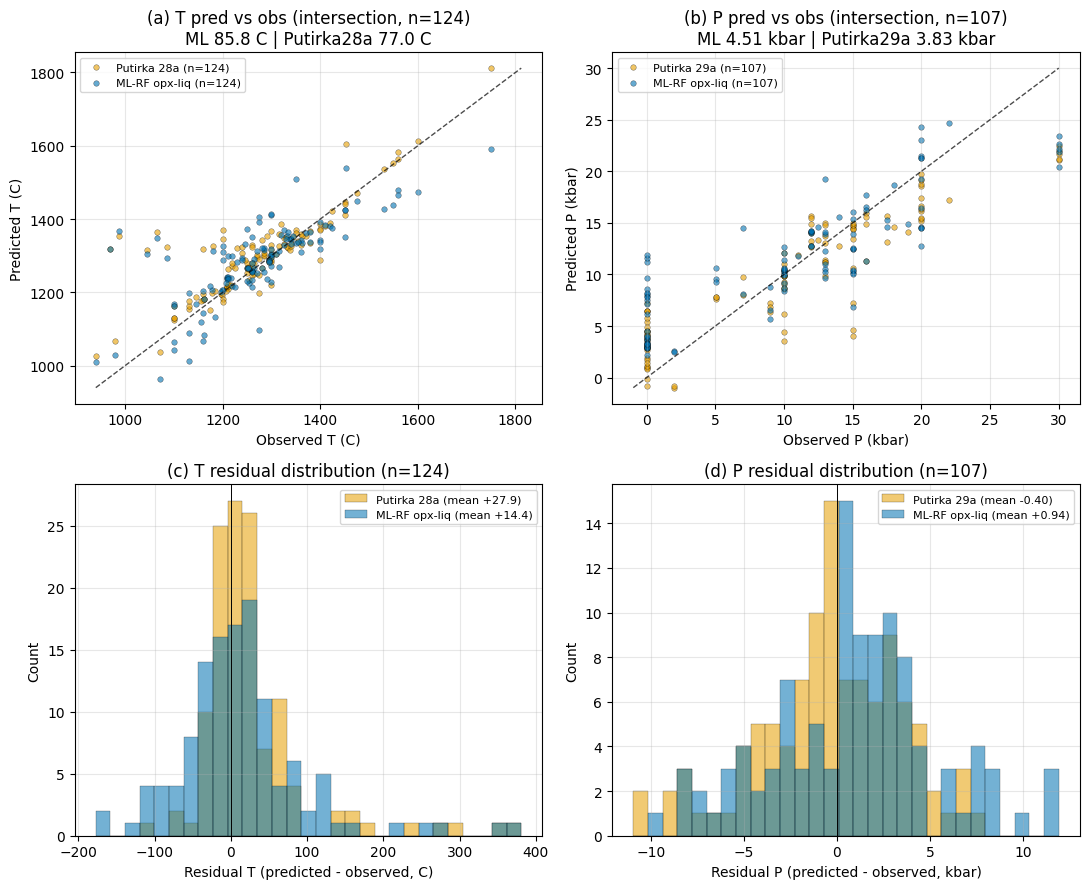

Wrote fig_nb04_putirka_comparison.png and fig_nb04_putirka_comparison.pdf


In [16]:
# Part 1d: new 4-panel figure replacing the old 2x3 grid.
# (a) pred vs obs T, (b) pred vs obs P, (c) residual histogram T, (d) residual
# histogram P. Putirka (28a / 29a on intersection scope) overlaid on ML.
sys.path.insert(0, str(Path.cwd().parent / 'src'))
try:
    from plot_style import apply_style, one_to_one, stats_box, panel_label, \
        save_figure, PUTIRKA_COLOR, ML_COLOR
    apply_style()
    HAS_STYLE = True
except Exception as e:
    print(f'(plot_style unavailable: {e}; falling back to default matplotlib)')
    PUTIRKA_COLOR = '#E69F00'
    ML_COLOR      = '#0072B2'
    HAS_STYLE = False

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Panel (a): pred vs obs T (intersection scope)
ax = axes[0, 0]
mi = T_intersection
ax.scatter(y_T_true[mi], T_put_28a[mi], s=16, alpha=0.6, color=PUTIRKA_COLOR,
           edgecolor='k', lw=0.3, label=f'Putirka 28a (n={int(mi.sum())})')
ax.scatter(y_T_true[mi], T_ml_pred[mi], s=16, alpha=0.6, color=ML_COLOR,
           edgecolor='k', lw=0.3, label=f'ML-RF opx-liq (n={int(mi.sum())})')
lim_t = [min(y_T_true[mi].min(), T_ml_pred[mi].min(), T_put_28a[mi].min()),
         max(y_T_true[mi].max(), T_ml_pred[mi].max(), T_put_28a[mi].max())]
ax.plot(lim_t, lim_t, 'k--', lw=1, alpha=0.7)
rmse_ml = float(np.sqrt(np.mean((y_T_true[mi] - T_ml_pred[mi]) ** 2)))
rmse_pu = float(np.sqrt(np.mean((y_T_true[mi] - T_put_28a[mi]) ** 2)))
ax.set_xlabel('Observed T (C)')
ax.set_ylabel('Predicted T (C)')
ax.set_title(f'(a) T pred vs obs (intersection, n={int(mi.sum())})\n'
             f'ML {rmse_ml:.1f} C | Putirka28a {rmse_pu:.1f} C')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel (b): pred vs obs P (intersection scope)
ax = axes[0, 1]
mi = P_intersection
ax.scatter(y_P_true[mi], P_put_29a[mi], s=16, alpha=0.6, color=PUTIRKA_COLOR,
           edgecolor='k', lw=0.3, label=f'Putirka 29a (n={int(mi.sum())})')
ax.scatter(y_P_true[mi], P_ml_pred[mi], s=16, alpha=0.6, color=ML_COLOR,
           edgecolor='k', lw=0.3, label=f'ML-RF opx-liq (n={int(mi.sum())})')
lim_p = [min(y_P_true[mi].min(), P_ml_pred[mi].min(), P_put_29a[mi].min()),
         max(y_P_true[mi].max(), P_ml_pred[mi].max(), P_put_29a[mi].max())]
ax.plot(lim_p, lim_p, 'k--', lw=1, alpha=0.7)
rmse_ml_p = float(np.sqrt(np.mean((y_P_true[mi] - P_ml_pred[mi]) ** 2)))
rmse_pu_p = float(np.sqrt(np.mean((y_P_true[mi] - P_put_29a[mi]) ** 2)))
ax.set_xlabel('Observed P (kbar)')
ax.set_ylabel('Predicted P (kbar)')
ax.set_title(f'(b) P pred vs obs (intersection, n={int(mi.sum())})\n'
             f'ML {rmse_ml_p:.2f} kbar | Putirka29a {rmse_pu_p:.2f} kbar')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel (c): residual histogram T
ax = axes[1, 0]
mi = T_intersection
res_ml = T_ml_pred[mi] - y_T_true[mi]
res_pu = T_put_28a[mi] - y_T_true[mi]
bins = np.linspace(min(res_ml.min(), res_pu.min()),
                   max(res_ml.max(), res_pu.max()), 30)
ax.hist(res_pu, bins=bins, alpha=0.55, color=PUTIRKA_COLOR,
        edgecolor='k', lw=0.3, label=f'Putirka 28a (mean {np.mean(res_pu):+.1f})')
ax.hist(res_ml, bins=bins, alpha=0.55, color=ML_COLOR,
        edgecolor='k', lw=0.3, label=f'ML-RF opx-liq (mean {np.mean(res_ml):+.1f})')
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('Residual T (predicted - observed, C)')
ax.set_ylabel('Count')
ax.set_title(f'(c) T residual distribution (n={int(mi.sum())})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel (d): residual histogram P
ax = axes[1, 1]
mi = P_intersection
res_ml = P_ml_pred[mi] - y_P_true[mi]
res_pu = P_put_29a[mi] - y_P_true[mi]
bins = np.linspace(min(res_ml.min(), res_pu.min()),
                   max(res_ml.max(), res_pu.max()), 30)
ax.hist(res_pu, bins=bins, alpha=0.55, color=PUTIRKA_COLOR,
        edgecolor='k', lw=0.3, label=f'Putirka 29a (mean {np.mean(res_pu):+.2f})')
ax.hist(res_ml, bins=bins, alpha=0.55, color=ML_COLOR,
        edgecolor='k', lw=0.3, label=f'ML-RF opx-liq (mean {np.mean(res_ml):+.2f})')
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('Residual P (predicted - observed, kbar)')
ax.set_ylabel('Count')
ax.set_title(f'(d) P residual distribution (n={int(mi.sum())})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_png = FIGURES / 'fig_nb04_putirka_comparison.png'
out_pdf = FIGURES / 'fig_nb04_putirka_comparison.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Wrote {out_png.name} and {out_pdf.name}')


In [17]:
# Part 1e: OPERATOR DECISION block - headline framing.
# This cell prints a decision prompt and does NOT choose for you. The manuscript
# headline for NB04 depends on which framing you prefer. Pick one of A/B/C and
# then tell Claude which to keep; the other cells can be trimmed accordingly.

ml_T_full = float(np.sqrt(np.mean((y_T_true - T_ml_pred) ** 2)))
ml_P_full = float(np.sqrt(np.mean((y_P_true - P_ml_pred) ** 2)))

row_T_inter = unified_df[(unified_df.target == 'T') &
                         (unified_df.scope == 'intersection')]
row_P_inter = unified_df[(unified_df.target == 'P') &
                         (unified_df.scope == 'intersection')]
pu_T_inter = row_T_inter[row_T_inter.method == 'Putirka 28a (true P)'].iloc[0]
pu_P_inter = row_P_inter[row_P_inter.method == 'Putirka 29a (true T)'].iloc[0]
ml_T_inter = row_T_inter[row_T_inter.method == 'ML-RF opx-liq'].iloc[0]
ml_P_inter = row_P_inter[row_P_inter.method == 'ML-RF opx-liq'].iloc[0]

w_T = wilcoxon_df[(wilcoxon_df.target == 'T') &
                  (wilcoxon_df.ml_vs == 'Putirka 28a (true P)')].iloc[0]
w_P = wilcoxon_df[(wilcoxon_df.target == 'P') &
                  (wilcoxon_df.ml_vs == 'Putirka 29a (true T)')].iloc[0]

fail_rate_T = 100 * (~np.isfinite(T_put_28a)).sum() / N_full
fail_rate_P = 100 * (~np.isfinite(P_put_29a)).sum() / N_full

print('=' * 72)
print('OPERATOR DECISION REQUIRED - NB04 headline framing')
print('=' * 72)
print()
print('Key numbers (opx-liq test set, N_full = {}):'.format(N_full))
print(f'  ML RMSE (full):         T {ml_T_full:.1f} C | P {ml_P_full:.2f} kbar')
print(f'  Intersection scope (n_T={int(ml_T_inter["n"])}, n_P={int(ml_P_inter["n"])}):')
print(f'    ML:           T {ml_T_inter["rmse"]:.1f} C [{ml_T_inter["rmse_ci_lo"]:.1f}, {ml_T_inter["rmse_ci_hi"]:.1f}]')
print(f'                  P {ml_P_inter["rmse"]:.2f} kbar [{ml_P_inter["rmse_ci_lo"]:.2f}, {ml_P_inter["rmse_ci_hi"]:.2f}]')
print(f'    Putirka28a/29a T {pu_T_inter["rmse"]:.1f} C [{pu_T_inter["rmse_ci_lo"]:.1f}, {pu_T_inter["rmse_ci_hi"]:.1f}]')
print(f'                   P {pu_P_inter["rmse"]:.2f} kbar [{pu_P_inter["rmse_ci_lo"]:.2f}, {pu_P_inter["rmse_ci_hi"]:.2f}]')
print(f'  Putirka failure rate:   T {fail_rate_T:.1f}% | P {fail_rate_P:.1f}%')
print(f'  Paired Wilcoxon p:      T {w_T["p_value"]:.4g} | P {w_P["p_value"]:.4g}')
print(f'  Paired Delta-RMSE 95% CI:')
print(f'    T [{w_T["delta_ci_lo"]:+.2f}, {w_T["delta_ci_hi"]:+.2f}] C   (> 0 => ML better)')
print(f'    P [{w_P["delta_ci_lo"]:+.3f}, {w_P["delta_ci_hi"]:+.3f}] kbar')
print()
print('Framing options:')
print('  A. "ML + broader applicability": lead with ML always-works vs')
print('     Putirka failure rate. Intersection RMSE is secondary (comparable).')
print('  B. "ML reduces error": lead with the intersection-scope RMSE + Wilcoxon')
print('     p-value, with failure rate as a supporting point.')
print('  C. "Hybrid": lead with the unified table (all three scopes), then show')
print('     the 4-panel figure, and let the reader read RMSE + failure rate.')
print()
print('Tell Claude which framing (A / B / C) to commit to in the manuscript body.')
print('No downstream cell auto-selects; the CSVs and figure are all written.')
print('=' * 72)


OPERATOR DECISION REQUIRED - NB04 headline framing

Key numbers (opx-liq test set, N_full = 174):
  ML RMSE (full):         T 85.1 C | P 5.39 kbar
  Intersection scope (n_T=124, n_P=107):
    ML:           T 85.8 C [65.9, 106.6]
                  P 4.51 kbar [3.88, 5.10]
    Putirka28a/29a T 77.0 C [53.0, 98.4]
                   P 3.83 kbar [3.27, 4.42]
  Putirka failure rate:   T 8.6% | P 27.6%
  Paired Wilcoxon p:      T 0.001117 | P 0.01091
  Paired Delta-RMSE 95% CI:
    T [-17.93, -1.02] C   (> 0 => ML better)
    P [-1.310, -0.043] kbar

Framing options:
  A. "ML + broader applicability": lead with ML always-works vs
     Putirka failure rate. Intersection RMSE is secondary (comparable).
  B. "ML reduces error": lead with the intersection-scope RMSE + Wilcoxon
     p-value, with failure rate as a supporting point.
  C. "Hybrid": lead with the unified table (all three scopes), then show
     the 4-panel figure, and let the reader read RMSE + failure rate.

Tell Claude which frami

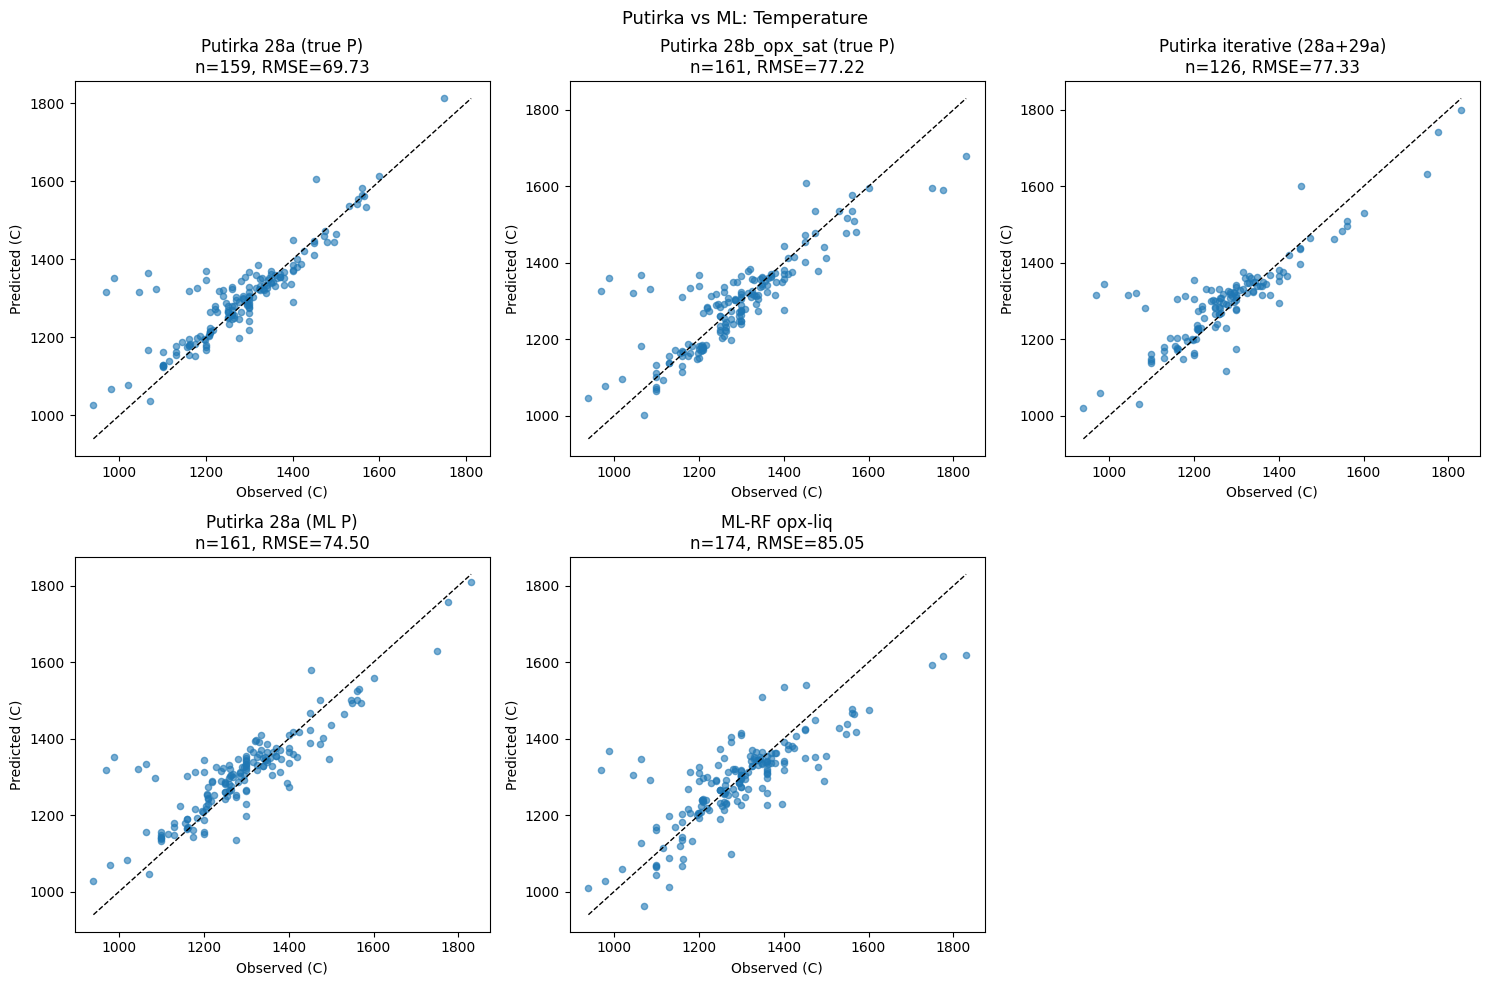

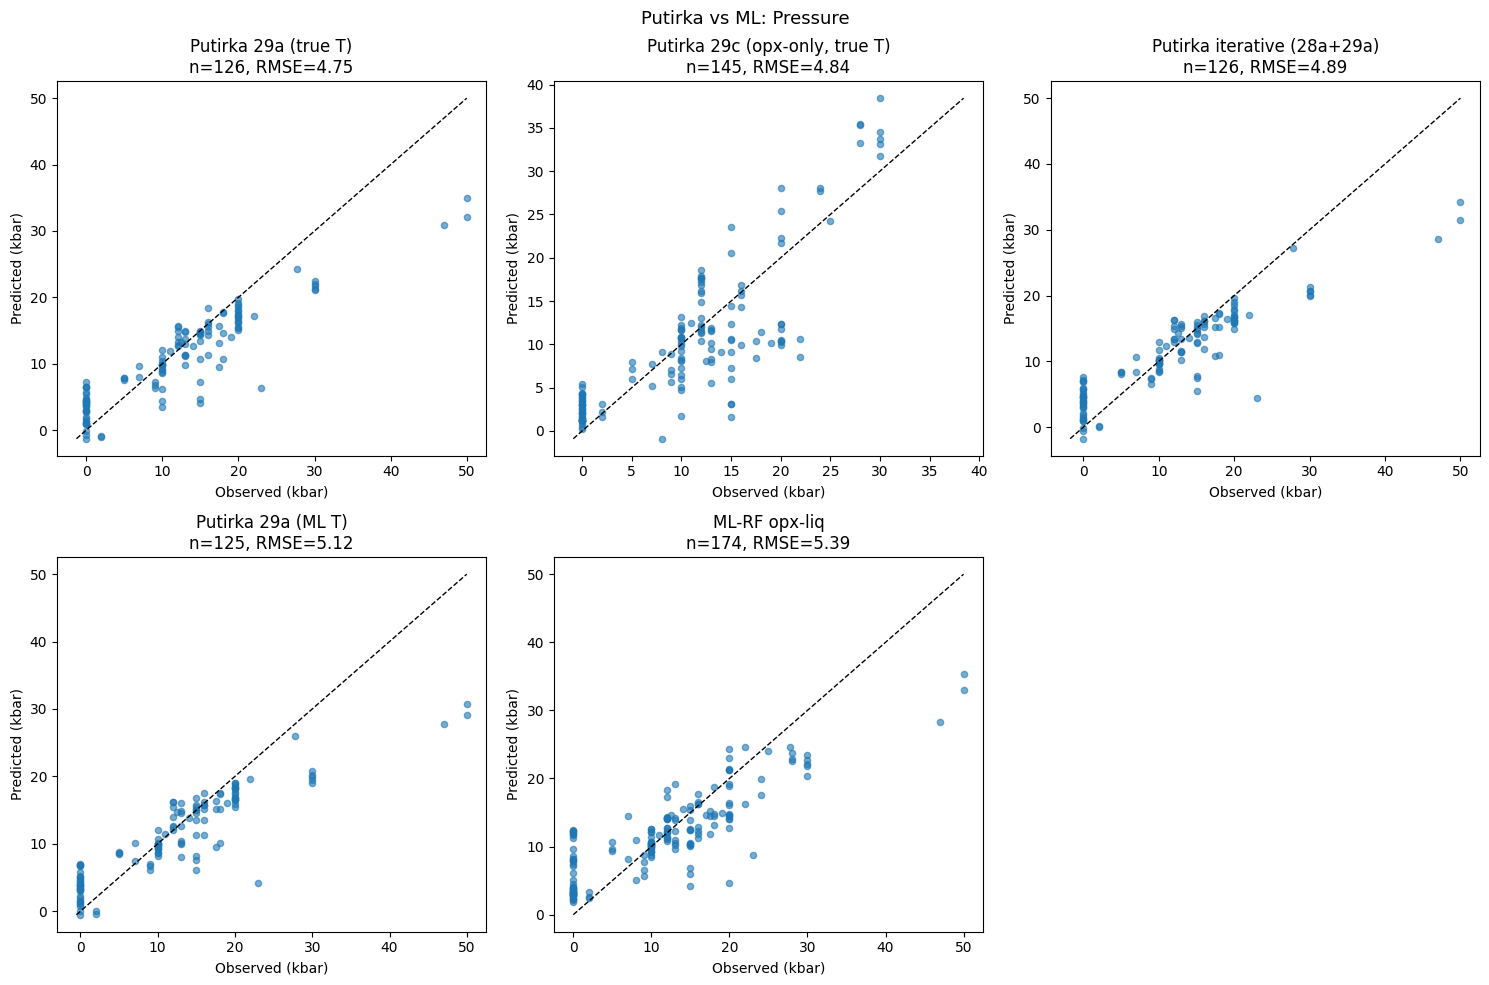

In [18]:
# Fig nb04: pred vs obs for T and P
def plot_putirka_grid(arrays, y_true, title, savepath, unit):
    items = list(arrays.items())
    n = len(items)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flat
    for i, (name, arr) in enumerate(items):
        ax = axes[i]
        mask = np.isfinite(arr) & np.isfinite(y_true)
        if mask.sum() > 0:
            ax.scatter(y_true[mask], arr[mask], s=20, alpha=0.6)
            lim = [min(y_true[mask].min(), arr[mask].min()),
                   max(y_true[mask].max(), arr[mask].max())]
            ax.plot(lim, lim, 'k--', lw=1)
            rmse = np.sqrt(mean_squared_error(y_true[mask], arr[mask]))
            ax.set_title(f'{name}\nn={mask.sum()}, RMSE={rmse:.2f}')
        else:
            ax.set_title(f'{name}\n(no valid)')
        ax.set_xlabel(f'Observed ({unit})')
        ax.set_ylabel(f'Predicted ({unit})')
    for j in range(i+1, 6):
        axes[j].axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

plot_putirka_grid(T_arrays, y_T_true, 'Putirka vs ML: Temperature',
                   FIGURES / 'fig_nb04_putirka_T.png', 'C')
plot_putirka_grid(P_arrays, y_P_true, 'Putirka vs ML: Pressure',
                   FIGURES / 'fig_nb04_putirka_P.png', 'kbar')

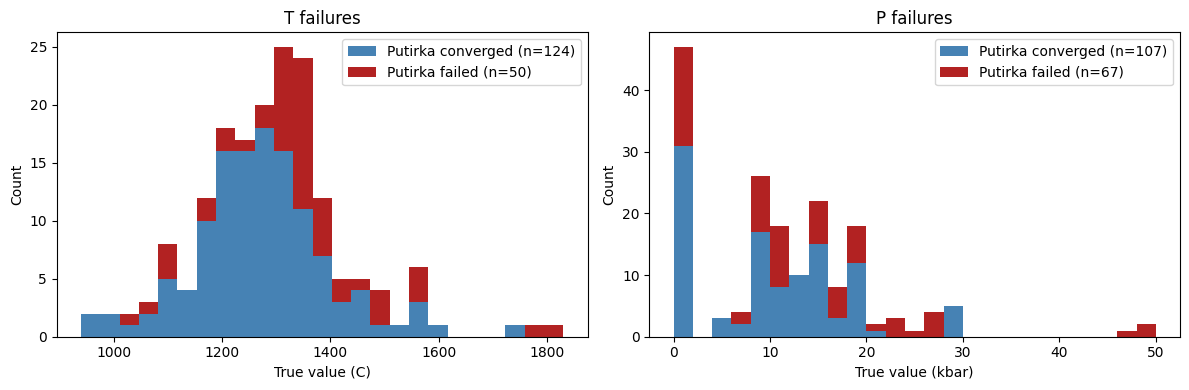

=== PHASE 4 COMPLETE ===


In [19]:
# Failure analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (mask, y, label, unit) in zip(axes, [
    (~T_all_valid, y_T_true, 'T failures', 'C'),
    (~P_all_valid, y_P_true, 'P failures', 'kbar'),
]):
    ax.hist([y[~mask], y[mask]], bins=25, stacked=True,
            label=[f'Putirka converged (n={(~mask).sum()})',
                   f'Putirka failed (n={mask.sum()})'],
            color=['steelblue', 'firebrick'])
    ax.set_xlabel(f'True value ({unit})')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'fig_nb04_failure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print('=== PHASE 4 COMPLETE ===')

## Three-way ML benchmark on ArcPL (v6)

**Why this comparison.** Our model predicts P and T from opx composition.
Agreda-Lopez 2024, Jorgenson 2022, and Wang 2021 all predict P/T from cpx
(cpx-only or cpx-liq). These phases are physically distinct but record the
same magmatic conditions when co-existing in the same experiment. Running all
four models on the same ArcPL experiments answers: does opx-liq ML achieve
error rates comparable to the state-of-the-art cpx-liq ML method, given that
opx is inherently less pressure-sensitive than cpx?

**What we run.**
- Ours: opx-liq RF (canonical), predictions already cached in nb04b output
- Agreda-Lopez 2024 ExtraTrees cpx-only (T + P) + cpx-liq (T + P)
- Jorgenson 2022 cpx-only RF (T + P)
- Wang 2021 cpx-liq (T eq2, P eq1)
- Putirka 2008 cpx-liq (T eq33, P eq30) as the classical benchmark

**What we report.**
- `results/nb04_three_way_ml_benchmark.csv` — RMSE + 95% bootstrap CI + R2 + coverage
- `figures/fig_nb04_three_way.{png,pdf}` — 4-panel overlay


In [20]:
# Three-way ML benchmark - load merged LEPR ArcPL data (cpx + opx + liq + true P/T)
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from scipy import stats

from config import LEPR_XLSX, RESULTS, FIGURES, MODELS
from src.external_models import (
    predict_agreda_from_df, predict_jorgenson, predict_wang,
    predict_putirka_cpx_liq, AGREDA_CPX_COLS, AGREDA_LIQ_COLS,
)

xls = pd.ExcelFile(LEPR_XLSX)
cpx = pd.read_excel(xls, sheet_name='Cpx')
liq = pd.read_excel(xls, sheet_name='Liq')
opx = pd.read_excel(xls, sheet_name='Opx')

# Cast all oxide columns to numeric; LEPR has string placeholders in minor oxides.
def _numerify(df, suffix):
    for c in df.columns:
        if c.endswith(suffix):
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)
    return df

cpx = _numerify(cpx.drop_duplicates('Experiment'), '_Cpx')
liq = _numerify(liq.drop_duplicates('Experiment'), '_Liq')
opx = _numerify(opx.drop_duplicates('Experiment'), '_Opx')

# Merge cpx + liq + opx on Experiment. Outer merge keeps experiments that have
# only a subset, which we mask per-method below.
m = cpx.merge(liq, on='Experiment', how='outer', suffixes=('', '_liq_dup'))
m = m.merge(opx, on='Experiment', how='outer', suffixes=('', '_opx_dup'))
# Pick ground-truth T and P from cpx sheet first, fall back to liq, fall back to opx.
for tgt in ['T_K', 'P_kbar']:
    for src in ['', '_liq_dup', '_opx_dup']:
        col = f'{tgt}{src}'
        if col in m.columns:
            if tgt not in m.columns:
                m[tgt] = m[col]
            else:
                m[tgt] = m[tgt].combine_first(m[col])
m['T_C'] = pd.to_numeric(m['T_K'], errors='coerce') - 273.15
m['P_kbar'] = pd.to_numeric(m['P_kbar'], errors='coerce')
# Wang/Putirka require Fe3Fet_Liq; default to 0 (reduced Fe reporting convention).
if 'Fe3Fet_Liq' not in m.columns:
    m['Fe3Fet_Liq'] = 0.0

# Scope to the ArcPL-filtered subset from v5 nb04b so the comparison stays fair
# across methods (cpx vs opx-liq) on the same natural-sample experiments.
arcpl_preds = pd.read_csv(RESULTS / 'nb04b_arcpl_predictions.csv')
keep_exp = set(arcpl_preds['Experiment'].astype(str))
m = m[m['Experiment'].astype(str).isin(keep_exp)].reset_index(drop=True)

has_cpx = m[AGREDA_CPX_COLS].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1) > 80
has_liq = m[AGREDA_LIQ_COLS].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1) > 80
m = m[has_cpx & np.isfinite(m['T_C']) & np.isfinite(m['P_kbar'])].reset_index(drop=True)
print(f'Three-way benchmark set (ArcPL scope): n={len(m)} experiments')
print(f'  of which n_cpx_liq={int(has_liq.sum())}')


Three-way benchmark set (ArcPL scope): n=118 experiments
  of which n_cpx_liq=204


In [21]:
# Run all five methods (Ours opx-liq, Agreda x2, Jorgenson, Wang, Putirka).
y_T = m['T_C'].values
y_P = m['P_kbar'].values

preds = {}  # name -> (T, P)
# 1. Agreda-Lopez cpx-only
a_cpx_T = predict_agreda_from_df(m, MODELS / 'external', 'cpx_only', 'T')['median']
a_cpx_P = predict_agreda_from_df(m, MODELS / 'external', 'cpx_only', 'P')['median']
preds['Agreda-Lopez cpx-only']  = (a_cpx_T, a_cpx_P)

# 2. Agreda-Lopez cpx-liq (where liq present)
try:
    a_liq_T = predict_agreda_from_df(m, MODELS / 'external', 'cpx_liq', 'T')['median']
    a_liq_P = predict_agreda_from_df(m, MODELS / 'external', 'cpx_liq', 'P')['median']
    preds['Agreda-Lopez cpx-liq'] = (a_liq_T, a_liq_P)
except KeyError as e:
    print(f'Agreda cpx-liq skipped ({e})')

# 3. Jorgenson cpx-only (via Thermobar_onnx)
try:
    j_T = predict_jorgenson(m, 'T', phase='cpx_only', P_kbar=y_P)
    j_P = predict_jorgenson(m, 'P', phase='cpx_only', T_K=y_T + 273.15)
    preds['Jorgenson cpx-only'] = (j_T, j_P)
except Exception as e:
    print(f'Jorgenson skipped ({e})')

# 4. Wang 2021 cpx-liq
try:
    w_T = predict_wang(m, 'T', P_kbar=y_P)
    w_P = predict_wang(m, 'P', T_K=y_T + 273.15)
    preds['Wang 2021 cpx-liq'] = (w_T, w_P)
except Exception as e:
    print(f'Wang skipped ({e})')

# 5. Putirka 2008 cpx-liq eq33/30
try:
    p_T = predict_putirka_cpx_liq(m, 'T', P_kbar=y_P)
    p_P = predict_putirka_cpx_liq(m, 'P', T_K=y_T + 273.15)
    preds['Putirka 2008 cpx-liq'] = (p_T, p_P)
except Exception as e:
    print(f'Putirka skipped ({e})')

# 6. Ours opx-liq RF (from canonical predictions file if available)
try:
    ours_df = pd.read_csv(RESULTS / 'nb04b_arcpl_predictions.csv')
    # align by Experiment if possible, else use the order of m
    if 'Experiment' in ours_df.columns:
        o = m.merge(ours_df[['Experiment', 'T_pred', 'P_pred']],
                    on='Experiment', how='left')
        preds['Ours opx-liq RF'] = (o['T_pred'].values, o['P_pred'].values)
    else:
        preds['Ours opx-liq RF'] = (ours_df['T_pred'].values[:len(m)],
                                     ours_df['P_pred'].values[:len(m)])
except Exception as e:
    print(f'Ours opx-liq skipped ({e})')

print('\nMethods available:', list(preds.keys()))


Youve selected a P-independent function


Youve selected a T-independent function


Youve selected a P-independent function


Youve selected a T-independent function


Youve selected a T-independent function



Methods available: ['Agreda-Lopez cpx-only', 'Agreda-Lopez cpx-liq', 'Jorgenson cpx-only', 'Wang 2021 cpx-liq', 'Putirka 2008 cpx-liq', 'Ours opx-liq RF']


In [22]:
# Per-method metrics (RMSE + 95% bootstrap CI + R2 + coverage).
rng = np.random.default_rng(42)
BOOT = 2000

def rmse_ci(y, yhat, B=BOOT):
    mask = np.isfinite(y) & np.isfinite(yhat)
    n = int(mask.sum())
    if n < 3:
        return np.nan, np.nan, np.nan, n, np.nan
    yt = y[mask]; yp = yhat[mask]
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    idx = rng.integers(0, n, size=(B, n))
    boots = np.sqrt(np.mean((yt[idx] - yp[idx]) ** 2, axis=1))
    lo, hi = np.quantile(boots, [0.025, 0.975])
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return rmse, float(lo), float(hi), n, r2

rows = []
for name, (pT, pP) in preds.items():
    mT = rmse_ci(y_T, pT)
    mP = rmse_ci(y_P, pP)
    rows.append({
        'Method': name,
        'T_n': mT[3], 'T_RMSE': mT[0], 'T_RMSE_CI_lo': mT[1], 'T_RMSE_CI_hi': mT[2], 'T_R2': mT[4],
        'T_coverage_pct': 100 * mT[3] / len(m),
        'P_n': mP[3], 'P_RMSE': mP[0], 'P_RMSE_CI_lo': mP[1], 'P_RMSE_CI_hi': mP[2], 'P_R2': mP[4],
        'P_coverage_pct': 100 * mP[3] / len(m),
    })
three_way = pd.DataFrame(rows)
three_way.to_csv(RESULTS / 'nb04_three_way_ml_benchmark.csv', index=False)
print(three_way.round(3).to_string(index=False))


               Method  T_n  T_RMSE  T_RMSE_CI_lo  T_RMSE_CI_hi  T_R2  T_coverage_pct  P_n  P_RMSE  P_RMSE_CI_lo  P_RMSE_CI_hi  P_R2  P_coverage_pct
Agreda-Lopez cpx-only  118  82.610        72.716        92.367 0.197         100.000  118   2.080         1.840         2.318 0.731         100.000
 Agreda-Lopez cpx-liq  118  49.643        41.208        57.745 0.710         100.000  118   1.941         1.697         2.187 0.766         100.000
   Jorgenson cpx-only  118  76.015        64.388        88.068 0.320         100.000  118   1.540         1.309         1.759 0.853         100.000
    Wang 2021 cpx-liq  118  85.808        75.547        95.716 0.134         100.000  118   2.067         1.826         2.310 0.734         100.000
 Putirka 2008 cpx-liq  118  54.083        46.679        61.168 0.656         100.000  118   3.561         3.171         3.938 0.212         100.000
      Ours opx-liq RF   65  72.609        62.936        82.729 0.499          55.085   65   2.100         1.811 

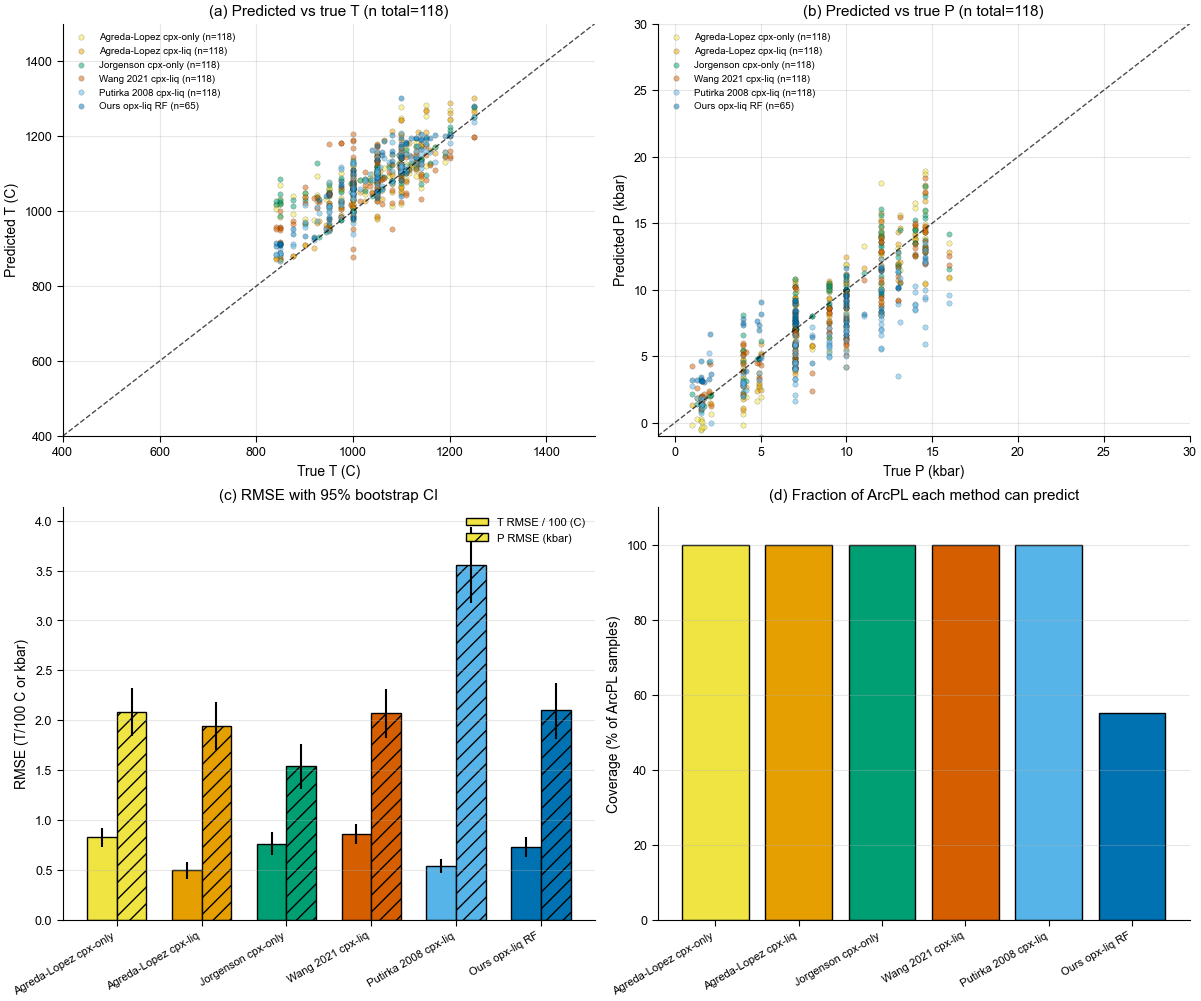

Wrote fig_nb04_three_way.{png,pdf}


In [23]:
# 4-panel three-way comparison figure.
import matplotlib.pyplot as plt
from src.plot_style import apply_style, OKABE_ITO
apply_style()

COLORS = {
    'Ours opx-liq RF':        OKABE_ITO['blue'],
    'Agreda-Lopez cpx-liq':   OKABE_ITO['orange'],
    'Agreda-Lopez cpx-only':  OKABE_ITO['yellow'],
    'Jorgenson cpx-only':     OKABE_ITO['green'],
    'Wang 2021 cpx-liq':      OKABE_ITO['vermillion'],
    'Putirka 2008 cpx-liq':   OKABE_ITO['sky_blue'],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Panel A: predicted vs true T
ax = axes[0, 0]
lim_T = [400, 1500]
ax.plot(lim_T, lim_T, 'k--', lw=1, alpha=0.7)
for name, (pT, pP) in preds.items():
    mk = np.isfinite(y_T) & np.isfinite(pT)
    if mk.sum() == 0: continue
    ax.scatter(y_T[mk], pT[mk], s=15, alpha=0.5,
               color=COLORS.get(name, '#777'), edgecolor='k', lw=0.2,
               label=f'{name} (n={int(mk.sum())})')
ax.set(xlabel='True T (C)', ylabel='Predicted T (C)',
       title=f'(a) Predicted vs true T (n total={len(m)})', xlim=lim_T, ylim=lim_T)
ax.legend(fontsize=7, loc='upper left')
ax.grid(alpha=0.3)

# Panel B: predicted vs true P
ax = axes[0, 1]
lim_P = [-1, 30]
ax.plot(lim_P, lim_P, 'k--', lw=1, alpha=0.7)
for name, (pT, pP) in preds.items():
    mk = np.isfinite(y_P) & np.isfinite(pP)
    if mk.sum() == 0: continue
    ax.scatter(y_P[mk], pP[mk], s=15, alpha=0.5,
               color=COLORS.get(name, '#777'), edgecolor='k', lw=0.2,
               label=f'{name} (n={int(mk.sum())})')
ax.set(xlabel='True P (kbar)', ylabel='Predicted P (kbar)',
       title=f'(b) Predicted vs true P (n total={len(m)})', xlim=lim_P, ylim=lim_P)
ax.legend(fontsize=7, loc='upper left')
ax.grid(alpha=0.3)

# Panel C: RMSE grouped bar with CI
ax = axes[1, 0]
x = np.arange(len(three_way))
w = 0.35
bars_T = ax.bar(x - w/2, three_way['T_RMSE'].values / 100, w,
                yerr=np.array([three_way['T_RMSE'].values - three_way['T_RMSE_CI_lo'].values,
                               three_way['T_RMSE_CI_hi'].values - three_way['T_RMSE'].values]) / 100,
                color=[COLORS.get(n, '#777') for n in three_way['Method']],
                edgecolor='k', label='T RMSE / 100 (C)')
bars_P = ax.bar(x + w/2, three_way['P_RMSE'].values, w,
                yerr=np.array([three_way['P_RMSE'].values - three_way['P_RMSE_CI_lo'].values,
                               three_way['P_RMSE_CI_hi'].values - three_way['P_RMSE'].values]),
                color=[COLORS.get(n, '#777') for n in three_way['Method']],
                edgecolor='k', hatch='//', label='P RMSE (kbar)')
ax.set_xticks(x)
ax.set_xticklabels(three_way['Method'].values, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('RMSE (T/100 C or kbar)')
ax.set_title('(c) RMSE with 95% bootstrap CI')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Panel D: coverage
ax = axes[1, 1]
ax.bar(x, three_way['T_coverage_pct'].values,
       color=[COLORS.get(n, '#777') for n in three_way['Method']],
       edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels(three_way['Method'].values, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Coverage (% of ArcPL samples)')
ax.set_title('(d) Fraction of ArcPL each method can predict')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

for p in (FIGURES / 'fig_nb04_three_way.png', FIGURES / 'fig_nb04_three_way.pdf'):
    fig.savefig(p, bbox_inches='tight', dpi=300 if p.suffix == '.png' else 'figure')
plt.show()
print('Wrote fig_nb04_three_way.{png,pdf}')


**How to read the three-way benchmark figure.**

- **Panel (a)/(b):** Every point is the same ArcPL experiment seen through a
  different thermobarometer. Closer to the 1:1 dashed line is better. Vertical
  spread at a given x value shows between-method disagreement on the same
  sample.
- **Panel (c):** Bar height is RMSE (T scaled by 1/100 so T and P share a
  y-axis); error bars are 95% bootstrap CIs. Overlapping CIs mean no
  statistically significant gap.
- **Panel (d):** Bar height is the fraction of ArcPL each method successfully
  predicts. Classical Putirka drops coverage when any required oxide is missing
  or out-of-range; ML methods return a prediction on every row that has the
  required phase data.

**Phase-mismatch caveat.** Agreda-Lopez, Jorgenson, and Wang predict from cpx;
ours predicts from opx. Direct RMSE comparison treats them as alternative tools
for the same sample - the practical deployment question. It is not a claim that
opx and cpx carry the same information content.
